In [ ]:
%matplotlib inline
import sys, os, copy, json
import torch
import torch.nn as nn
import numpy as np
import torchvision
from torch.utils.data import DataLoader

sys.path.append('..')
from src.data.degredation import get_transforms
from torchvision.models import resnet18
from src.training.train import train, test
from src.training.random_training import random_train # random2
from src.evaluation.inference import get_predictions_and_confidence #random2
from src.visualization.overconfidence_plots import plot_confidence_distribution, plot_logit_distribution # random2

import matplotlib.pyplot as plt
from custom.figure import mm, color

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams['font.family'] = 'DejaVu Sans'

def resnet18():
    """Standard torchvision resnet18 architecture, randomly initialized from scratch."""
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return model

dataset_dir = "../dataset"
train_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=True, download=True,
    transform=get_transforms("cifar10", blur=0, color=1, test=False, imagenet_resize=True))
train_degradation_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=True, download=True,
    transform=get_transforms("cifar10", blur=7, color=0, test=False, imagenet_resize=True))
test_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=False, download=True,
    transform=get_transforms("cifar10", blur=0, color=1, test=True, imagenet_resize=True))
test_degradation_dataset = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=False, download=True,
    transform=get_transforms("cifar10", blur=7, color=0, test=True, imagenet_resize=True))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
train_degradation_loader = DataLoader(train_degradation_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)
test_degradation_loader = DataLoader(test_degradation_dataset, batch_size=128, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)}  Train(degraded): {len(train_degradation_dataset)}  "
      f"Test: {len(test_dataset)}  Test(degraded): {len(test_degradation_dataset)}")


c:\Users\vslab#1\Desktop\Chaewon\critical-period\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 50000  Train(degraded): 50000  Test: 10000  Test(degraded): 10000


In [2]:
dir = "cifar10-scratch-224" # from torchvision 
num_net = 20

figure_dir = os.path.join("..", "figures", dir)
save_dir = os.path.join("..", "results", dir)
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

criterion = nn.CrossEntropyLoss()
num_noise, input_shape, output_size = 50000, (3, 224, 224), 10
lr_target = 0.0001
snapshot_interval = 10


In [3]:
conditions, models, optimizers, schedulers, training_info = {}, {}, {}, {}, {}

def ckpt_path(tag, i): return os.path.join(save_dir, f"best_model_{tag}_{i}.pth")
def info_path(tag, i): return os.path.join(save_dir, f"training_info_{tag}_{i}.json")
def snapshot_path(tag, i, epoch): return os.path.join(save_dir, f"snapshot_{tag}_{i}_epoch{epoch}.pth")


In [4]:
# R: random-noise warm-up
# Random2 get_predictions_and_confidence, 모델만 ResNet - chance level = 1/output_size)
def warmup(tag, r):
    conf_after_all, logit_after_all = [], []
    for i in range(num_net):
        if os.path.exists(ckpt_path(tag, i)):
            _, conf, _, _, logit = get_predictions_and_confidence(
                models[tag][i], test_loader, device=device, return_logits=True)
            print(f"[{tag}] net {i} already trained (confidence={conf.mean():.3f})") # chance level = 0.1 
            print(f"[{tag}] net {i} logit stats: min={logit.min():.2f} max={logit.max():.2f} std={logit.std():.2f}")
            conf_after_all.append(conf)
            logit_after_all.append(logit)
            continue

        opt_noise = torch.optim.SGD(models[tag][i].parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
        for epoch in range(r):
            loss, acc = random_train(models[tag][i], opt_noise, criterion, input_shape, num_noise,
                                      batch_size=256, output_size=output_size, device=device)
            print(f"[{tag}] net {i} warm-up epoch {epoch+1}/{r} loss={loss:.4f} acc={acc:.4f}")

        _, conf_after, _, _, logit_after = get_predictions_and_confidence(
            models[tag][i], test_loader, device=device, return_logits=True)
        print(f"[{tag}] net {i} logit stats: min={logit_after.min():.2f} max={logit_after.max():.2f} std={logit_after.std():.2f}")

        conf_after_all.append(conf_after);   logit_after_all.append(logit_after)

    chance = 1 / output_size
    if conf_after_all:
        plot_confidence_distribution(np.concatenate(conf_after_all), color["sky"],
                                      f"{tag} ({len(conf_after_all)} nets)", chance_level=chance)
        plot_logit_distribution(np.concatenate(logit_after_all), color["sky"],
                                 f"{tag} ({len(conf_after_all)} nets)")
        plt.show()


In [5]:
def run_epochs(tag, n, r=0, g=0, l=0, lr_start=None, base_tag=None):
    if tag not in conditions:
        lr_start = lr_target if lr_start is None else lr_start
        conditions[tag] = dict(lr_start=lr_start, use_degradation=g > 0, degradation_window=g,
                                use_lr_suppress=l > 0, lr_suppress_start=l)
        models[tag] = [resnet18().to(device) for _ in range(num_net)]
        optimizers[tag] = [torch.optim.Adam(models[tag][i].parameters(), lr=lr_start) for i in range(num_net)]
        schedulers[tag] = [torch.optim.lr_scheduler.StepLR(optimizers[tag][i], step_size=50, gamma=0.1) for i in range(num_net)]
        training_info[tag] = [dict(train_loss=[], train_acc=[], test_loss=[], test_acc=[], best_acc=0.0, lr_suppressed=False)
                               for _ in range(num_net)]
        for i in range(num_net):
            if os.path.exists(ckpt_path(tag, i)):
                models[tag][i].load_state_dict(torch.load(ckpt_path(tag, i), map_location=device))
                if os.path.exists(info_path(tag, i)):
                    with open(info_path(tag, i)) as f:
                        training_info[tag][i].update(json.load(f))
            elif base_tag is not None:
                # Seed from base_tag's converged checkpoint instead of redoing noise warm-up.
                if not os.path.exists(ckpt_path(base_tag, i)):
                    raise FileNotFoundError(f"base_tag '{base_tag}' has no checkpoint for net {i} -- run it first")
                models[tag][i].load_state_dict(torch.load(ckpt_path(base_tag, i), map_location=device))
        if base_tag is None:
            warmup(tag, r)
    else:
        print(f"[{tag}] already exists")
        for i in range(num_net):
            _, conf, _, _, _ = get_predictions_and_confidence(
                models[tag][i], test_loader, device=device, return_logits=True)
            print(f"[{tag}] net {i} confidence: {conf.mean():.3f}  (chance=1/{output_size}={1/output_size:.3f})")

    cfg = conditions[tag]
    for i in range(num_net):
        model, optimizer, scheduler = models[tag][i], optimizers[tag][i], schedulers[tag][i]
        info = training_info[tag][i]
        start = len(info["test_acc"])
        for epoch in range(start, start + n):
            if cfg["use_lr_suppress"] and not info["lr_suppressed"] and epoch >= cfg["lr_suppress_start"]:
                for grp in optimizer.param_groups:
                    grp["lr"] = lr_target
                info["lr_suppressed"] = True

            degrading = cfg["use_degradation"] and epoch < cfg["degradation_window"]
            loader = train_degradation_loader if degrading else train_loader
            train_loss, train_acc = train(model, loader, optimizer, criterion, scheduler, device)
            test_loss, test_acc = test(model, test_loader, criterion, device)

            info["train_loss"].append(train_loss); info["train_acc"].append(train_acc)
            info["test_loss"].append(test_loss); info["test_acc"].append(test_acc)

            if epoch % snapshot_interval == 0:
                torch.save(model.state_dict(), snapshot_path(tag, i, epoch))
            if test_acc > info["best_acc"]:
                info["best_acc"] = test_acc
                torch.save(model.state_dict(), ckpt_path(tag, i))
                with open(info_path(tag, i), "w") as f:
                    json.dump(info, f)

            print(f"[{tag}] net {i} epoch {epoch} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")

R hyperparameter searching - r=2 

[r0] net 0 logit stats: min=-103.06 max=37.06 std=19.05
[r0] net 1 logit stats: min=-48.10 max=21.47 std=9.11
[r0] net 2 logit stats: min=-26.76 max=66.20 std=14.32
[r0] net 3 logit stats: min=-79.36 max=39.26 std=14.52
[r0] net 4 logit stats: min=-58.26 max=27.96 std=9.95
[r0] net 5 logit stats: min=-42.95 max=28.59 std=9.06
[r0] net 6 logit stats: min=-21.42 max=15.37 std=5.75
[r0] net 7 logit stats: min=-39.03 max=60.57 std=18.15
[r0] net 8 logit stats: min=-58.62 max=27.78 std=11.06
[r0] net 9 logit stats: min=-67.29 max=102.87 std=19.18
[r0] net 10 logit stats: min=-41.31 max=21.01 std=8.04
[r0] net 11 logit stats: min=-47.40 max=147.18 std=20.91
[r0] net 12 logit stats: min=-23.11 max=53.04 std=11.33
[r0] net 13 logit stats: min=-31.39 max=53.38 std=12.51
[r0] net 14 logit stats: min=-37.49 max=61.64 std=14.22
[r0] net 15 logit stats: min=-45.69 max=38.63 std=12.95
[r0] net 16 logit stats: min=-81.40 max=94.49 std=19.35
[r0] net 17 logit stats: min=-17.13 max=37.48 std=8.94
[r0] 

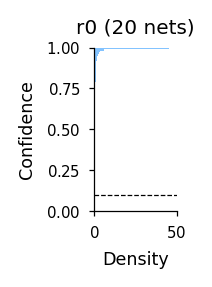

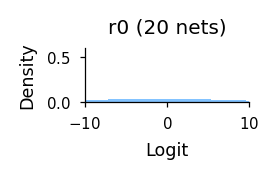

In [15]:
run_epochs("r0", 0, r=0)
for i in range(num_net):
    torch.save(models["r0"][i]. state_dict(), ckpt_path("r0", i))

[r1] net 0 warm-up epoch 1/1 loss=2.8309 acc=0.0995
[r1] net 0 logit stats: min=-8.68 max=16.35 std=3.51
[r1] net 1 warm-up epoch 1/1 loss=2.8396 acc=0.0988
[r1] net 1 logit stats: min=-5.93 max=55.90 std=4.96
[r1] net 2 warm-up epoch 1/1 loss=2.9136 acc=0.0988
[r1] net 2 logit stats: min=-18.04 max=15.04 std=2.38
[r1] net 3 warm-up epoch 1/1 loss=3.1535 acc=0.1012
[r1] net 3 logit stats: min=-12.66 max=20.25 std=3.16
[r1] net 4 warm-up epoch 1/1 loss=3.1763 acc=0.0988
[r1] net 4 logit stats: min=-26.15 max=2.67 std=2.55
[r1] net 5 warm-up epoch 1/1 loss=3.0417 acc=0.0993
[r1] net 5 logit stats: min=-18.86 max=18.67 std=2.56
[r1] net 6 warm-up epoch 1/1 loss=2.9187 acc=0.0994
[r1] net 6 logit stats: min=-19.56 max=37.80 std=3.93
[r1] net 7 warm-up epoch 1/1 loss=2.9186 acc=0.1024
[r1] net 7 logit stats: min=-31.50 max=15.34 std=2.89
[r1] net 8 warm-up epoch 1/1 loss=2.8491 acc=0.1016
[r1] net 8 logit stats: min=-32.50 max=5.05 std=3.09
[r1] net 9 warm-up epoch 1/1 loss=3.0478 acc=0.100

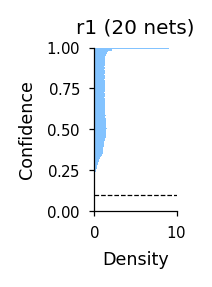

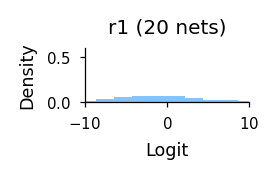

In [16]:
# to check random confidence level

run_epochs("r1", 0, r=1)
for i in range(num_net):
    torch.save(models["r1"][i]. state_dict(), ckpt_path("r1", i))

[r2] net 0 warm-up epoch 1/2 loss=2.8312 acc=0.0995
[r2] net 0 warm-up epoch 2/2 loss=2.4569 acc=0.1002
[r2] net 0 logit stats: min=-6.30 max=13.34 std=3.29
[r2] net 1 warm-up epoch 1/2 loss=2.8756 acc=0.0985
[r2] net 1 warm-up epoch 2/2 loss=2.4201 acc=0.1001
[r2] net 1 logit stats: min=1.88 max=13.64 std=0.96
[r2] net 2 warm-up epoch 1/2 loss=3.0258 acc=0.0999
[r2] net 2 warm-up epoch 2/2 loss=2.4123 acc=0.0984
[r2] net 2 logit stats: min=-4.29 max=6.64 std=1.88
[r2] net 3 warm-up epoch 1/2 loss=2.9647 acc=0.1011
[r2] net 3 warm-up epoch 2/2 loss=2.4376 acc=0.1018
[r2] net 3 logit stats: min=-7.16 max=3.24 std=0.99
[r2] net 4 warm-up epoch 1/2 loss=2.9353 acc=0.0974
[r2] net 4 warm-up epoch 2/2 loss=2.4359 acc=0.0993
[r2] net 4 logit stats: min=-16.11 max=12.38 std=1.67
[r2] net 5 warm-up epoch 1/2 loss=2.8885 acc=0.1005
[r2] net 5 warm-up epoch 2/2 loss=2.4812 acc=0.0984
[r2] net 5 logit stats: min=-8.17 max=10.06 std=2.89
[r2] net 6 warm-up epoch 1/2 loss=2.9866 acc=0.0990
[r2] net

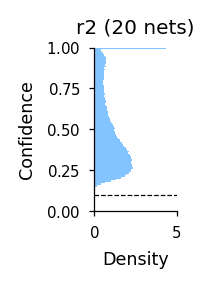

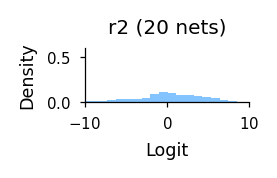

In [17]:
run_epochs("r2", 0, r=2)
for i in range(num_net):
    torch.save(models["r2"][i]. state_dict(), ckpt_path("r2", i))

[r3] net 0 warm-up epoch 1/3 loss=2.8839 acc=0.1017
[r3] net 0 warm-up epoch 2/3 loss=2.4649 acc=0.1012
[r3] net 0 warm-up epoch 3/3 loss=2.4067 acc=0.0998
[r3] net 0 logit stats: min=-8.54 max=9.38 std=1.09
[r3] net 1 warm-up epoch 1/3 loss=2.9517 acc=0.0999
[r3] net 1 warm-up epoch 2/3 loss=2.4609 acc=0.0986
[r3] net 1 warm-up epoch 3/3 loss=2.4129 acc=0.1005
[r3] net 1 logit stats: min=-6.13 max=3.33 std=0.98
[r3] net 2 warm-up epoch 1/3 loss=2.9524 acc=0.1014
[r3] net 2 warm-up epoch 2/3 loss=2.4790 acc=0.1009
[r3] net 2 warm-up epoch 3/3 loss=2.3944 acc=0.1008
[r3] net 2 logit stats: min=-4.22 max=20.85 std=1.65
[r3] net 3 warm-up epoch 1/3 loss=2.9160 acc=0.1006
[r3] net 3 warm-up epoch 2/3 loss=2.4498 acc=0.1031
[r3] net 3 warm-up epoch 3/3 loss=2.3992 acc=0.0971
[r3] net 3 logit stats: min=-22.87 max=2.65 std=1.76
[r3] net 4 warm-up epoch 1/3 loss=2.9418 acc=0.0998
[r3] net 4 warm-up epoch 2/3 loss=2.4567 acc=0.0988
[r3] net 4 warm-up epoch 3/3 loss=2.3985 acc=0.1016
[r3] net 4

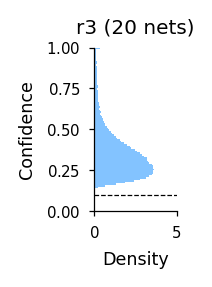

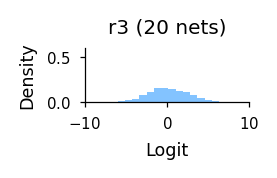

In [18]:
run_epochs("r3", 0, r=3)
for i in range(num_net):
    torch.save(models["r3"][i]. state_dict(), ckpt_path("r3", i))

[r4] net 0 warm-up epoch 1/4 loss=2.7310 acc=0.0984
[r4] net 0 warm-up epoch 2/4 loss=2.4446 acc=0.0986
[r4] net 0 warm-up epoch 3/4 loss=2.3936 acc=0.0980
[r4] net 0 warm-up epoch 4/4 loss=2.3831 acc=0.1000
[r4] net 0 logit stats: min=-8.38 max=1.27 std=0.82
[r4] net 1 warm-up epoch 1/4 loss=2.9449 acc=0.1009
[r4] net 1 warm-up epoch 2/4 loss=2.4337 acc=0.1000
[r4] net 1 warm-up epoch 3/4 loss=2.3989 acc=0.1002
[r4] net 1 warm-up epoch 4/4 loss=2.3771 acc=0.1033
[r4] net 1 logit stats: min=-10.77 max=0.78 std=1.35
[r4] net 2 warm-up epoch 1/4 loss=2.9178 acc=0.1006
[r4] net 2 warm-up epoch 2/4 loss=2.4411 acc=0.0982
[r4] net 2 warm-up epoch 3/4 loss=2.3987 acc=0.1005
[r4] net 2 warm-up epoch 4/4 loss=2.3883 acc=0.0996
[r4] net 2 logit stats: min=-15.25 max=2.75 std=1.16
[r4] net 3 warm-up epoch 1/4 loss=3.1549 acc=0.0981
[r4] net 3 warm-up epoch 2/4 loss=2.4185 acc=0.1010
[r4] net 3 warm-up epoch 3/4 loss=2.4117 acc=0.0995
[r4] net 3 warm-up epoch 4/4 loss=2.3736 acc=0.1012
[r4] net 3

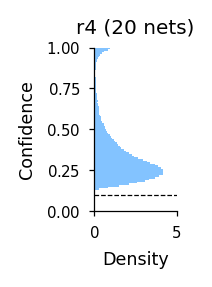

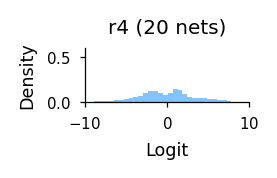

In [7]:
run_epochs("r4", 0, r=4)
for i in range(num_net):
    torch.save(models["r4"][i]. state_dict(), ckpt_path("r4", i))

[r5] net 0 warm-up epoch 1/5 loss=2.9671 acc=0.1008
[r5] net 0 warm-up epoch 2/5 loss=2.4371 acc=0.0973
[r5] net 0 warm-up epoch 3/5 loss=2.3854 acc=0.1015
[r5] net 0 warm-up epoch 4/5 loss=2.3683 acc=0.1000
[r5] net 0 warm-up epoch 5/5 loss=2.3559 acc=0.1024
[r5] net 0 logit stats: min=-3.04 max=4.55 std=0.97
[r5] net 1 warm-up epoch 1/5 loss=3.1757 acc=0.0971
[r5] net 1 warm-up epoch 2/5 loss=2.4632 acc=0.0980
[r5] net 1 warm-up epoch 3/5 loss=2.4056 acc=0.1002
[r5] net 1 warm-up epoch 4/5 loss=2.4016 acc=0.0988
[r5] net 1 warm-up epoch 5/5 loss=2.3902 acc=0.1012
[r5] net 1 logit stats: min=-11.08 max=-0.48 std=1.07
[r5] net 2 warm-up epoch 1/5 loss=2.9202 acc=0.1010
[r5] net 2 warm-up epoch 2/5 loss=2.4928 acc=0.1028
[r5] net 2 warm-up epoch 3/5 loss=2.4078 acc=0.1023
[r5] net 2 warm-up epoch 4/5 loss=2.3946 acc=0.0994
[r5] net 2 warm-up epoch 5/5 loss=2.3758 acc=0.1005
[r5] net 2 logit stats: min=-7.56 max=2.06 std=0.61
[r5] net 3 warm-up epoch 1/5 loss=2.9573 acc=0.1006
[r5] net 3

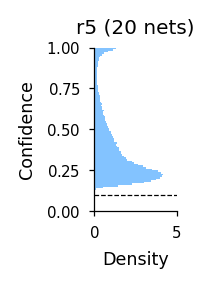

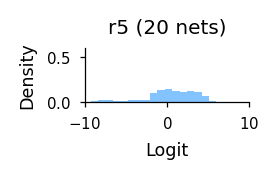

In [8]:
run_epochs("r5", 0, r=5)
for i in range(num_net):
    torch.save(models["r5"][i]. state_dict(), ckpt_path("r5", i))

In [ ]:
run_epochs("r6", 0, r=5)
for i in range(num_net):
    torch.save(models["r6"][i]. state_dict(), ckpt_path("r6", i))

In [ ]:
# run_epochs(tag, n, r=0, g=0, l=0, lr_start=None)

run_epochs("wo", 10)
run_epochs("r5g5l5", 10, r=5, g=5, l=5, lr_start=0.001)


Gradual schedule sweep -- base r3, varying g (degradation window) / l (lr-suppress start)

All conditions below load r3's converged checkpoint via `base_tag="r3"` instead of redoing the noise warm-up, so every arm starts from identical weights.

In [6]:
# run_epochs(tag, n, r=0, g=0, l=0, lr_start=None, base_tag=None)
# n = downstream epoch count for that condition (n = max(g, l), so both the
# degradation window and the lr-suppress epoch actually get to fire).

gradual_configs = [
    # tag        n     g  l
    ("r3g1",     1, 1, 0),
    ("r3g1l1",   1, 1, 1),
    ("r3g1l2",   2, 1, 2),
    ("r3g2",     2, 2, 0),
    ("r3g2l1",   2, 2, 1),
    ("r3g2l2",   2, 2, 2),
    ("r3g2l3",   3, 2, 3),
    ("r3g2l4",   4, 2, 4),
    ("r3g3",     3, 3, 0),
    ("r3g3l1",   3, 3, 1),
    ("r3g3l2",   3, 3, 2),
    ("r3g3l3",   3, 3, 3),
    ("r3g3l4",   4, 3, 4),
    ("r3g3l5",   5, 3, 5),
    # g-only sweep (l=0), g=4..10
    ("r3g4",     4, 4, 0),
    ("r3g5",     5, 5, 0),
    ("r3g6",     6, 6, 0),
    ("r3g7",     7, 7, 0),
    ("r3g8",     8, 8, 0),
    ("r3g9",     9, 9, 0),
    ("r3g10",   10, 10, 0),
]

for tag, n, g, l in gradual_configs:
    run_epochs(tag, n, g=g, l=l, lr_start=0.01, base_tag="r3")

[r3g1] net 0 epoch 0 train_acc=0.2435 test_acc=0.2382
[r3g1] net 1 epoch 0 train_acc=0.2474 test_acc=0.3178
[r3g1] net 2 epoch 0 train_acc=0.2273 test_acc=0.2573
[r3g1] net 3 epoch 0 train_acc=0.1750 test_acc=0.2633
[r3g1] net 4 epoch 0 train_acc=0.2456 test_acc=0.2087
[r3g1] net 5 epoch 0 train_acc=0.2158 test_acc=0.2892
[r3g1] net 6 epoch 0 train_acc=0.2329 test_acc=0.2288
[r3g1] net 7 epoch 0 train_acc=0.2469 test_acc=0.2642
[r3g1] net 8 epoch 0 train_acc=0.2110 test_acc=0.2412
[r3g1] net 9 epoch 0 train_acc=0.2257 test_acc=0.2803
[r3g1] net 10 epoch 0 train_acc=0.2547 test_acc=0.2926
[r3g1] net 11 epoch 0 train_acc=0.2040 test_acc=0.2823
[r3g1] net 12 epoch 0 train_acc=0.2277 test_acc=0.2297
[r3g1] net 13 epoch 0 train_acc=0.2076 test_acc=0.2101
[r3g1] net 14 epoch 0 train_acc=0.2443 test_acc=0.2531
[r3g1] net 15 epoch 0 train_acc=0.2464 test_acc=0.2526
[r3g1] net 16 epoch 0 train_acc=0.2354 test_acc=0.2292
[r3g1] net 17 epoch 0 train_acc=0.2550 test_acc=0.2188
[r3g1] net 18 epoch 

KeyboardInterrupt: 

In [ ]:
# Blur classification check: how well each gradual-schedule model classifies
# blurred (blur=7, color=0) CIFAR-10 test images, as a proxy for "typical image" input.

print(f"{'tag':<10} {'blur test acc':<20} {'clean test acc'}")
for tag, _, _, _ in gradual_configs:
    blur_accs, clean_accs = [], []
    for i in range(num_net):
        model = models[tag][i]
        _, blur_acc = test(model, test_degradation_loader, criterion, device)
        _, clean_acc = test(model, test_loader, criterion, device)
        blur_accs.append(blur_acc)
        clean_accs.append(clean_acc)
    blur_accs, clean_accs = np.array(blur_accs), np.array(clean_accs)
    print(f"{tag:<10} {blur_accs.mean():.4f} ± {blur_accs.std():.4f}      "
          f"{clean_accs.mean():.4f} ± {clean_accs.std():.4f}")

tag        blur test acc        clean test acc
r3g1       0.2813 ± 0.0305      0.2537 ± 0.0365
r3g1l1     0.3095 ± 0.0252      0.2721 ± 0.0269
r3g1l2     0.1998 ± 0.0313      0.5109 ± 0.0467


In [ ]:
palette = plt.cm.tab10(np.linspace(0, 1, len(conditions)))
plt.figure(figsize=(80 * mm, 50 * mm))
for (tag, cfg), col in zip(conditions.items(), palette):
    for i in range(num_net):
        curve = training_info[tag][i]["test_acc"]
        if len(curve) > 1:
            plt.plot(curve, color=col, alpha=0.3)
    plt.plot([], [], color=col, label=tag)
plt.xlabel("Epoch")
plt.ylabel("Clean Test Accuracy")
plt.title("Test accuracy by condition")
plt.legend(fontsize=6, ncol=2)
plt.savefig(os.path.join(figure_dir, "test_acc_by_condition.svg"))

r3g1..r3g10 sweep, all with n=10 (fixed downstream epoch count regardless of g), warm-up reused from `r3`'s converged checkpoint via `base_tag="r3"`. Each config gets its own cell so results can be inspected independently.

Clear any remaining r3g1..r3g10 state (in-memory dicts + on-disk checkpoints/info/snapshots) before re-running the sweep below with the default lr_target=0.0001.

In [15]:
run_epochs("r3g1", 1, g=1, base_tag="r3")


[r3g1] already exists


KeyboardInterrupt: 

In [16]:
run_epochs("r3g2", 2, g=2, base_tag="r3")


[r3g2] already exists


KeyboardInterrupt: 

In [17]:
run_epochs("r3g3", 3, g=3, base_tag="r3")


[r3g3] net 0 epoch 0 train_acc=0.3458 test_acc=0.1261
[r3g3] net 0 epoch 1 train_acc=0.4618 test_acc=0.2180
[r3g3] net 0 epoch 2 train_acc=0.5347 test_acc=0.2647
[r3g3] net 1 epoch 0 train_acc=0.3596 test_acc=0.2173
[r3g3] net 1 epoch 1 train_acc=0.4822 test_acc=0.2937
[r3g3] net 1 epoch 2 train_acc=0.5529 test_acc=0.2954
[r3g3] net 2 epoch 0 train_acc=0.3627 test_acc=0.2644
[r3g3] net 2 epoch 1 train_acc=0.4835 test_acc=0.2878
[r3g3] net 2 epoch 2 train_acc=0.5470 test_acc=0.3264
[r3g3] net 3 epoch 0 train_acc=0.3640 test_acc=0.1349
[r3g3] net 3 epoch 1 train_acc=0.4908 test_acc=0.2509
[r3g3] net 3 epoch 2 train_acc=0.5560 test_acc=0.3096
[r3g3] net 4 epoch 0 train_acc=0.3505 test_acc=0.2232
[r3g3] net 4 epoch 1 train_acc=0.4708 test_acc=0.2148
[r3g3] net 4 epoch 2 train_acc=0.5434 test_acc=0.2825
[r3g3] net 5 epoch 0 train_acc=0.3550 test_acc=0.2255


KeyboardInterrupt: 

In [ ]:
run_epochs("r3g4", 4, g=4, base_tag="r3")


In [ ]:
run_epochs("r3g5", 5, g=5, base_tag="r3")


In [ ]:
run_epochs("r3g6", 6, g=6, base_tag="r3")


In [ ]:
run_epochs("r3g8", 8, g=8, base_tag="r3")


In [ ]:
run_epochs("r3g10", 10, g=10, base_tag="r3")
